# Customer Sales Data Cleaning & Analysis Using Python

This project focuses on cleaning and analyzing customer sales data using Python.

The goal is to identify missing values, duplicate records, incorrect data types, outliers, sales trends, product performance, customer behavior, and business insights.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

## Project Steps

1. Import libraries
2. Create raw dataset
3. Explore the data
4. Identify missing values and duplicate records
5. Clean the dataset
6. Fix data types
7. Create calculated columns
8. Analyze sales performance
9. Visualize key insights
10. Export cleaned dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns',None)
pd.set_option('display.width',1000)

## 1. Create Raw Dataset

In this step, I created a raw customer sales dataset with intentional data quality issues such as missing values, duplicate records, inconsistent text formatting, incorrect data types, and unusual values.

This helps simulate a real-world data cleaning process.

In [2]:
data = {
    'order_id': [
        1001, 1002, 1003, 1004, 1005,
        1006, 1007, 1008, 1009, 1010,
        1011, 1012, 1013, 1014, 1015,
        1016, 1017, 1018, 1019, 1020,
        1021, 1022, 1023, 1024, 1025,
        1025
    ],
    'customer_id': [
        'C001', 'C002', 'C003', 'C004', 'C005',
        'C006', 'C007', 'C008', 'C009', 'C010',
        'C011', 'C012', 'C013', 'C014', 'C015',
        'C016', 'C017', 'C018', 'C019', 'C020',
        'C021', 'C022', 'C023', 'C024', 'C025',
        'C025'
    ],
    'customer_name': [
        'Customer 001', 'Customer 002', 'Customer 003', 'Customer 004', 'Customer 005',
        'Customer 006', 'Customer 007', 'Customer 008', 'Customer 009', 'Customer 010',
        'Customer 011', 'Customer 012', 'Customer 013', 'Customer 014', 'Customer 015',
        'Customer 016', 'Customer 017', 'Customer 018', 'Customer 019', 'Customer 020',
        'Customer 021', 'Customer 022', 'Customer 023', 'Customer 024', 'Customer 025',
        'Customer 025'
    ],
    'city': [
        'Tehran', 'tehran', 'Isfahan', 'Mashhad', 'Shiraz',
        'Tabriz', 'Rasht', 'Tehran', 'Isfahan', 'mashhad',
        'Shiraz', 'Tabriz', 'Rasht', 'Tehran', 'Isfahan',
        'Mashhad', 'Shiraz', 'tabriz', 'Rasht', 'Tehran',
        'Isfahan', 'Mashhad', 'Shiraz', None, 'Tehran',
        'Tehran'
    ],
    'order_date': [
        '2024-01-05', '2024/01/12', '2024-02-03', '15-02-2024', '2024-03-01',
        '2024-03-12', '2024/04/05', '2024-04-18', '2024-05-02', '2024-05-17',
        '2024-06-01', '2024/06/10', '2024-06-25', '2024-07-02', '2024-07-15',
        '2024-08-01', '2024-08-12', '2024/08/25', '2024-09-04', '2024-09-20',
        '2024-10-01', '2024-10-15', '2024/11/03', '2024-11-18', '2024-12-05',
        '2024-12-05'
    ],
    'product_category': [
        'Electronics', 'electronics', 'Clothing', 'Home', 'Beauty',
        'Electronics', 'Clothing', 'Home', 'Beauty', 'Electronics',
        'Home', 'Clothing', 'Beauty', 'Electronics', 'Home',
        'Clothing', 'Beauty', 'Electronics', 'Home', 'Clothing',
        'Beauty', 'Electronics', 'Home', 'Clothing', 'Beauty',
        'Beauty'
    ],
    'quantity': [
        1, 2, 3, 1, 2,
        1, 4, 2, 3, 1,
        2, 3, 1, 2, 1,
        3, 2, 1, 2, 4,
        1, 2, 1, np.nan, 3,
        3
    ],
    'unit_price': [
        '1200', '300', '50', '450', '80',
        '1500', '40', '600', '70', '2000',
        '500', '45', '90', '1300', '700',
        '55', '85', '2500', '650', '60',
        '95', '1800', '750', '50', '100',
        '100'
    ],
    'payment_method': [
        'Card', 'card', 'Cash', 'Online', 'Card',
        'Online', 'Cash', 'Card', 'Online', 'Card',
        'Cash', 'card', 'Online', 'Card', 'Online',
        'Cash', 'Card', 'Online', 'Cash', 'Card',
        'Online', 'Card', 'Cash', 'Online', None,
        None
    ],
    'order_status': [
        'Completed', 'Completed', 'Completed', 'Returned', 'Completed',
        'Completed', 'Completed', 'Completed', 'Cancelled', 'Completed',
        'Completed', 'Completed', 'Completed', 'Completed', 'Returned',
        'Completed', 'Completed', 'Completed', 'Completed', 'Completed',
        'Cancelled', 'Completed', 'Completed', 'Completed', 'Completed',
        'Completed'
    ]
}

df_raw = pd.DataFrame(data)

df_raw.head()

,order_id,customer_id,customer_name,city,order_date,product_category,quantity,unit_price,payment_method,order_status
0,1001,C001,Customer 001,Tehran,2024-01-05,Electronics,1.0,1200,Card,Completed
1,1002,C002,Customer 002,tehran,2024/01/12,electronics,2.0,300,card,Completed
2,1003,C003,Customer 003,Isfahan,2024-02-03,Clothing,3.0,50,Cash,Completed
3,1004,C004,Customer 004,Mashhad,15-02-2024,Home,1.0,450,Online,Returned
4,1005,C005,Customer 005,Shiraz,2024-03-01,Beauty,2.0,80,Card,Completed


## 2. Explore the Raw Dataset

In this step, I explored the raw dataset to understand its structure, number of rows and columns, data types, missing values, duplicate records, and basic statistical summary.

This step helps identify data quality issues before cleaning.

In [3]:
df_raw.shape

(26, 10)

In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          26 non-null     int64  
 1   customer_id       26 non-null     object 
 2   customer_name     26 non-null     object 
 3   city              25 non-null     object 
 4   order_date        26 non-null     object 
 5   product_category  26 non-null     object 
 6   quantity          25 non-null     float64
 7   unit_price        26 non-null     object 
 8   payment_method    24 non-null     object 
 9   order_status      26 non-null     object 
dtypes: float64(1), int64(1), object(8)
memory usage: 2.2+ KB


In [5]:
df_raw.isnull().sum()

order_id            0
customer_id         0
customer_name       0
city                1
order_date          0
product_category    0
quantity            1
unit_price          0
payment_method      2
order_status        0
dtype: int64

In [6]:
df_raw.duplicated().sum()

np.int64(1)

In [7]:
df_raw.describe(include='all')

,order_id,customer_id,customer_name,city,order_date,product_category,quantity,unit_price,payment_method,order_status
count,26.000000,26,26,25,26,26,25.000000,26,24,26
unique,NaN,25,25,9,25,5,NaN,24,4,3
top,NaN,C025,Customer 025,Tehran,2024-12-05,Beauty,NaN,100,Card,Completed
freq,NaN,2,2,6,2,7,NaN,2,8,22
mean,1013.461538,NaN,NaN,NaN,NaN,NaN,2.040000,NaN,NaN,NaN
std,7.585411,NaN,NaN,NaN,NaN,NaN,0.978093,NaN,NaN,NaN
min,1001.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
25%,1007.250000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
50%,1013.500000,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN
75%,1019.750000,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN


## 3. Clean the Dataset

In this step, I cleaned the raw dataset by removing duplicate records, fixing inconsistent text formatting, handling missing values, converting incorrect data types, and creating a clean version of the dataset for analysis.

In [8]:
df_clean = df_raw.copy()
# Remove duplicate records
df_clean = df_clean.drop_duplicates()

# Standardize city names
df_clean['city'] = df_clean['city'].fillna('Unknown')
df_clean['city'] = df_clean['city'].str.strip().str.title()

# Standardize product category names
df_clean['product_category'] = df_clean['product_category'].str.strip().str.title()

# Standardize payment method values
df_clean['payment_method'] = df_clean['payment_method'].fillna('Unknown')
df_clean['payment_method'] = df_clean['payment_method'].str.strip().str.title()

# Convert oder_date to datetime
df_clean['order_date'] = pd.to_datetime(df_clean['order_date'], errors='coerce')

# Convert quantity and unit_price to numeric values
df_clean['quantity'] = pd.to_numeric(df_clean['quantity'], errors='coerce')
df_clean['unit_price'] = pd.to_numeric(df_clean['unit_price'], errors='coerce')

# Fill missing quantity with median quantity
df_clean['quantity'] = df_clean['quantity'].fillna(df_clean['quantity'].median())

#Convert quantity to integer
df_clean['quantity'] = df_clean['quantity'].astype(int)

# Create total sales column
df_clean['total_sales'] = df_clean['quantity'] * df_clean['unit_price']

df_clean.head()

,order_id,customer_id,customer_name,city,order_date,product_category,quantity,unit_price,payment_method,order_status,total_sales
0,1001,C001,Customer 001,Tehran,2024-01-05,Electronics,1,1200,Card,Completed,1200
1,1002,C002,Customer 002,Tehran,NaT,Electronics,2,300,Card,Completed,600
2,1003,C003,Customer 003,Isfahan,2024-02-03,Clothing,3,50,Cash,Completed,150
3,1004,C004,Customer 004,Mashhad,NaT,Home,1,450,Online,Returned,450
4,1005,C005,Customer 005,Shiraz,2024-03-01,Beauty,2,80,Card,Completed,160


In [9]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25 entries, 0 to 24
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          25 non-null     int64         
 1   customer_id       25 non-null     object        
 2   customer_name     25 non-null     object        
 3   city              25 non-null     object        
 4   order_date        19 non-null     datetime64[ns]
 5   product_category  25 non-null     object        
 6   quantity          25 non-null     int64         
 7   unit_price        25 non-null     int64         
 8   payment_method    25 non-null     object        
 9   order_status      25 non-null     object        
 10  total_sales       25 non-null     int64         
dtypes: datetime64[ns](1), int64(4), object(6)
memory usage: 2.3+ KB


In [10]:
df_clean.isnull().sum()

order_id            0
customer_id         0
customer_name       0
city                0
order_date          6
product_category    0
quantity            0
unit_price          0
payment_method      0
order_status        0
total_sales         0
dtype: int64

In [11]:
df_clean.duplicated().sum()

np.int64(0)

In [12]:
df_clean.shape

(25, 11)

## 4. Create Analysis Columns

In this step, I created additional columns to make the dataset ready for business analysis.

These columns help analyze monthly sales trends, customer spending behavior, order status, and revenue performance.

In [13]:
# Standardize order status values
df_clean['order_status'] = df_clean['order_status'].str.strip().str.title()

# Create month column for time-based analysis
df_clean['order_month'] = df_clean['order_date'].dt.to_period('M')

# Create sales level based on total sales
df_clean['sales_level'] = np.where(
    df_clean['total_sales'] >= 1000,
    'High Sales Order',
    np.where(df_clean['total_sales'] >= 300, 'Medium Sales Order', 'Low Sales Order')
)

df_clean.head()

,order_id,customer_id,customer_name,city,order_date,product_category,quantity,unit_price,payment_method,order_status,total_sales,order_month,sales_level
0,1001,C001,Customer 001,Tehran,2024-01-05,Electronics,1,1200,Card,Completed,1200,2024-01,High Sales Order
1,1002,C002,Customer 002,Tehran,NaT,Electronics,2,300,Card,Completed,600,NaT,Medium Sales Order
2,1003,C003,Customer 003,Isfahan,2024-02-03,Clothing,3,50,Cash,Completed,150,2024-02,Low Sales Order
3,1004,C004,Customer 004,Mashhad,NaT,Home,1,450,Online,Returned,450,NaT,Medium Sales Order
4,1005,C005,Customer 005,Shiraz,2024-03-01,Beauty,2,80,Card,Completed,160,2024-03,Low Sales Order


## 5. Sales Performance Analysis

In this step, I analyzed completed orders to understand overall revenue, product category performance, city-based sales, monthly trends, payment methods, and customer behavior.

Cancelled and returned orders were excluded from revenue analysis to focus on actual completed sales.

In [14]:
df_completed = df_clean[df_clean['order_status'] == 'Completed'].copy()

df_completed.shape

(21, 13)

In [15]:
total_revenue = df_completed['total_sales'].sum()
total_orders = df_completed['order_id'].nunique()
average_order_value = df_completed['total_sales'].mean()

summary_metrics = pd.DataFrame({
    'Metric': ['Total Revenue', 'Total Orders', 'Average Order Value'],
    'Value': [total_revenue, total_orders, average_order_value]
})

summary_metrics

,Metric,Value
0,Total Revenue,19920.000000
1,Total Orders,21.000000
2,Average Order Value,948.571429


In [16]:
category_sales = df_completed.groupby('product_category')['total_sales'].sum().sort_values(ascending=False)

category_sales

product_category
Electronics    14000
Home            4250
Clothing         950
Beauty           720
Name: total_sales, dtype: int64

In [17]:
city_sales = df_completed.groupby('city')['total_sales'].sum().sort_values(ascending=False)

city_sales

city
Tehran     6140
Mashhad    5765
Tabriz     4135
Shiraz     2080
Rasht      1550
Isfahan     150
Unknown     100
Name: total_sales, dtype: int64

In [18]:
monthly_sales = df_completed.groupby('order_month')['total_sales'].sum()

monthly_sales

order_month
2024-01    1200
2024-02     150
2024-03    1660
2024-04    1200
2024-05    2000
2024-06    1090
2024-07    2600
2024-08     335
2024-09    1540
2024-10    3600
2024-11     100
2024-12     300
Freq: M, Name: total_sales, dtype: int64

In [19]:
order_status_count = df_clean['order_status'].value_counts()

order_status_count

order_status
Completed    21
Returned      2
Cancelled     2
Name: count, dtype: int64

## 6. Data Visualization

In this step, I visualized key business insights from the cleaned dataset, including revenue by product category, revenue by city, monthly sales trend, order status distribution, and payment method performance.

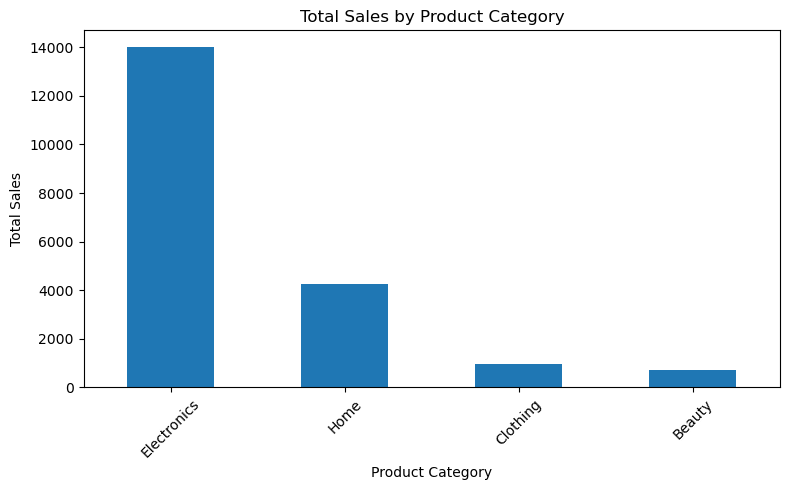

In [20]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind='bar')

plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

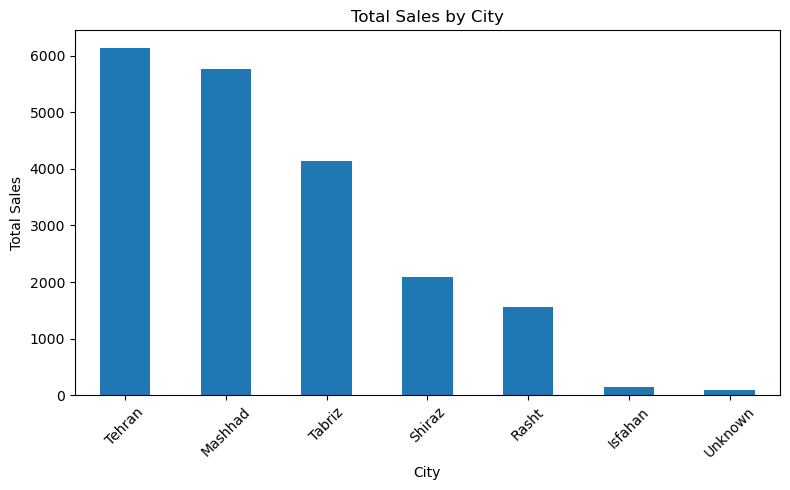

In [21]:
plt.figure(figsize=(8, 5))

city_sales.plot(kind='bar')

plt.title('Total Sales by City')
plt.xlabel('City')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

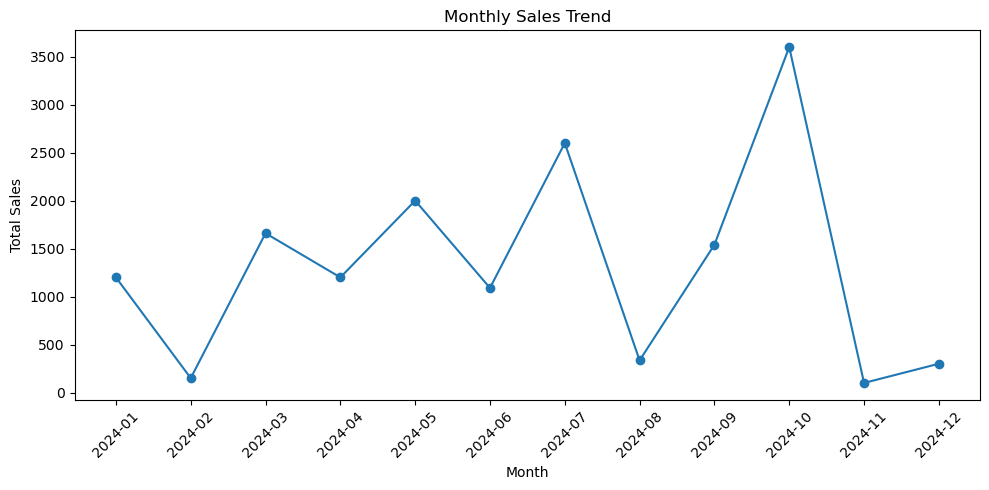

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

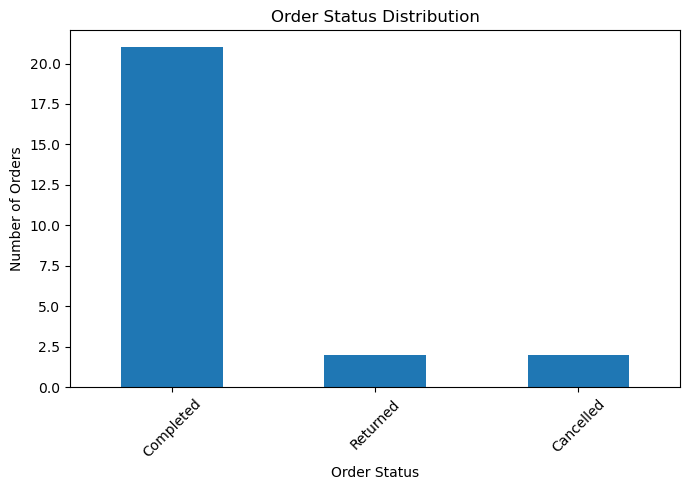

In [23]:
plt.figure(figsize=(7, 5))

order_status_count.plot(kind='bar')

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [24]:
payment_sales = df_completed.groupby('payment_method')['total_sales'].sum().sort_values(ascending=False)

payment_sales

payment_method
Card       11905
Online      4190
Cash        3525
Unknown      300
Name: total_sales, dtype: int64

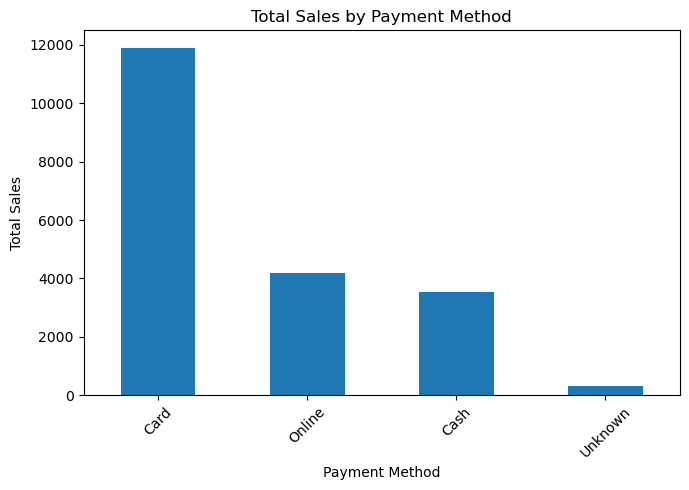

In [25]:
plt.figure(figsize=(7, 5))

payment_sales.plot(kind='bar')

plt.title('Total Sales by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [26]:
top_customers = df_completed.groupby('customer_id')['total_sales'].sum().sort_values(ascending=False).head(10)

top_customers

customer_id
C022    3600
C014    2600
C018    2500
C010    2000
C006    1500
C019    1300
C001    1200
C008    1200
C011    1000
C023     750
Name: total_sales, dtype: int64

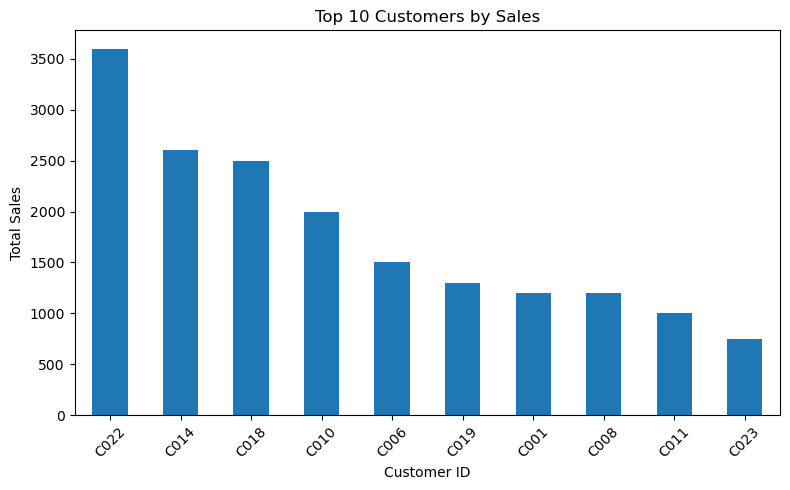

In [27]:
plt.figure(figsize=(8, 5))

top_customers.plot(kind='bar')

plt.title('Top 10 Customers by Sales')
plt.xlabel('Customer ID')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 7. Business Insights

In this step, I summarized the key insights from the cleaned customer sales dataset.

The goal is to translate the analysis into simple business findings that can support decision-making.

In [28]:
top_category = category_sales.idxmax()
top_category_revenue = category_sales.max()

top_city = city_sales.idxmax()
top_city_revenue = city_sales.max()

best_month = monthly_sales.idxmax()
best_month_revenue = monthly_sales.max()

top_payment_method = payment_sales.idxmax()
top_payment_revenue = payment_sales.max()

top_customer = top_customers.idxmax()
top_customer_revenue = top_customers.max()

completed_orders = len(df_completed)
total_orders_all = len(df_clean)
completed_order_rate = round((completed_orders / total_orders_all) * 100, 2)

business_insights = pd.DataFrame({
    'Insight Area': [
        'Top Product Category',
        'Top City',
        'Best Sales Month',
        'Top Payment Method',
        'Top Customer',
        'Completed Order Rate'
    ],
    'Result': [
        top_category,
        top_city,
        str(best_month),
        top_payment_method,
        top_customer,
        f'{completed_order_rate}%'
    ],
    'Value': [
        top_category_revenue,
        top_city_revenue,
        best_month_revenue,
        top_payment_revenue,
        top_customer_revenue,
        completed_orders
    ]
})

business_insights

,Insight Area,Result,Value
0,Top Product Category,Electronics,14000
1,Top City,Tehran,6140
2,Best Sales Month,2024-10,3600
3,Top Payment Method,Card,11905
4,Top Customer,C022,3600
5,Completed Order Rate,84.0%,21


### Key Findings

- The top product category generated the highest share of completed sales revenue.
- The top city contributed the most revenue among all customer locations.
- Monthly sales analysis helped identify the strongest sales period.
- Payment method analysis showed which payment channel generated the most completed sales.
- Customer-level analysis identified the highest-value customers.
- Cleaning the dataset improved data quality by handling missing values, duplicate records, inconsistent formatting, and incorrect data types.

## 8. Export Cleaned Dataset

In this final step, I exported the cleaned dataset as a CSV file so it can be reused for reporting, dashboarding, or further analysis.

In [29]:
df_clean.to_csv('cleaned_customer_sales_data.csv', index=False)

print('Cleaned dataset exported successfully.')

Cleaned dataset exported successfully.


In [30]:
df_clean.head()

,order_id,customer_id,customer_name,city,order_date,product_category,quantity,unit_price,payment_method,order_status,total_sales,order_month,sales_level
0,1001,C001,Customer 001,Tehran,2024-01-05,Electronics,1,1200,Card,Completed,1200,2024-01,High Sales Order
1,1002,C002,Customer 002,Tehran,NaT,Electronics,2,300,Card,Completed,600,NaT,Medium Sales Order
2,1003,C003,Customer 003,Isfahan,2024-02-03,Clothing,3,50,Cash,Completed,150,2024-02,Low Sales Order
3,1004,C004,Customer 004,Mashhad,NaT,Home,1,450,Online,Returned,450,NaT,Medium Sales Order
4,1005,C005,Customer 005,Shiraz,2024-03-01,Beauty,2,80,Card,Completed,160,2024-03,Low Sales Order


In [31]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25 entries, 0 to 24
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          25 non-null     int64         
 1   customer_id       25 non-null     object        
 2   customer_name     25 non-null     object        
 3   city              25 non-null     object        
 4   order_date        19 non-null     datetime64[ns]
 5   product_category  25 non-null     object        
 6   quantity          25 non-null     int64         
 7   unit_price        25 non-null     int64         
 8   payment_method    25 non-null     object        
 9   order_status      25 non-null     object        
 10  total_sales       25 non-null     int64         
 11  order_month       19 non-null     period[M]     
 12  sales_level       25 non-null     object        
dtypes: datetime64[ns](1), int64(4), object(7), period[M](1)
memory usage: 2.7+ KB


## 9. Project Conclusion

In this project, I cleaned and analyzed a raw customer sales dataset using Python.

The dataset included common real-world data quality issues such as missing values, duplicate records, inconsistent text formatting, incorrect data types, and mixed date formats.

After cleaning the dataset, I analyzed completed orders to understand revenue performance, product category sales, city-based sales, monthly sales trends, payment method performance, and top customers.

This project helped me practice:

- Data cleaning with Pandas
- Handling missing values and duplicate records
- Fixing inconsistent text formatting
- Converting data types
- Creating calculated columns
- Performing exploratory data analysis
- Building visualizations with Matplotlib
- Extracting business insights from cleaned data
- Exporting a cleaned dataset for further analysis

Overall, this project demonstrates how Python can be used to transform raw data into clean, structured, and useful business insights.